# 04. EDA — Análisis Exploratorio de Series Temporales

## Objetivo

Analizar el comportamiento temporal de las variables financieras de
Grupo Éxito durante el período 2020–2025, identificando tendencias,
estacionalidad, variaciones y relaciones que puedan ser relevantes
para la construcción de modelos de pronóstico.

### Etapas

1. Preparación de la serie temporal
2. Evolución de las variables financieras
3. Análisis de estacionalidad
4. Crecimiento interanual
5. Variación trimestre a trimestre
6. Análisis de tendencia y cambios estructurales (margenes)
7. Correlaciones y gráficos de dispersión
8. Análisis de tendencia y volatilidad

In [54]:
# Importación de librerias 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Carga de datos

df_financiero = pd.read_excel(r"C:\Users\USUARIO\Documents\GitHub\Sistema-de-Pronostico-Financiero-Grupo-Exito\data\Bronze\informe_resultados_exito.xlsx")

df_financiero.head()

,año,trimestre,fecha,ingresos,utilidad_bruta,ebitda_recurrente,resultado_neto
0,2025,1,2025-03-31,5404642,1382773,371148,93147
1,2025,2,2025-06-30,5208469,1335783,452242,146865
2,2025,3,2025-09-30,5228905,1312056,448017,142905
3,2025,4,2025-12-31,6166344,1612428,670615,209191
4,2024,1,2024-03-31,5275139,1321953,302113,-37863


###  1. Preparación serie temporal

In [3]:
# Ordenar cronológicamente

df_financiero = df_financiero.sort_values(by="fecha").reset_index(drop=True)

In [4]:
df_financiero[["año", "trimestre", "fecha"]]

,año,trimestre,fecha
0,2020,1,2020-03-31
1,2020,2,2020-06-30
2,2020,3,2020-09-30
3,2020,4,2020-12-31
4,2021,1,2021-03-31
5,2021,2,2021-06-30
6,2021,3,2021-09-30
7,2021,4,2021-12-31
8,2022,1,2022-03-31
9,2022,2,2022-06-30


In [5]:
# Creación de indice temporal

df_ts =df_financiero.copy()
df_ts = df_ts.set_index("fecha")

df_ts.head()

,año,trimestre,ingresos,utilidad_bruta,ebitda_recurrente,resultado_neto
fecha,,,,,,
2020-03-31,2020,1,4052431,1001122,262832,21987
2020-06-30,2020,2,3688456,911875,299143,12787
2020-09-30,2020,3,3649939,901871,249457,51814
2020-12-31,2020,4,4345013,1142061,460429,144284
2021-03-31,2021,1,3819172,1016535,306694,84957


In [6]:
# Comprobación de frecuencia temporal 

df_ts.index.to_series().diff().value_counts()

fecha
92 days    12
91 days     7
90 days     4
Name: count, dtype: int64

In [9]:
df_ts[["año","trimestre"]].head(10)

,año,trimestre
fecha,,
2020-03-31,2020,1
2020-06-30,2020,2
2020-09-30,2020,3
2020-12-31,2020,4
2021-03-31,2021,1
2021-06-30,2021,2
2021-09-30,2021,3
2021-12-31,2021,4
2022-03-31,2022,1


In [10]:
periodos = pd.PeriodIndex(df_ts.index, freq="Q")

print("Número de periodos:", len(periodos))
print("Períodos unicos:", periodos.nunique())

Número de periodos: 24
Períodos unicos: 24


In [11]:
# Creación de una variable temporal trimestral

df_ts["periodo"] = df_ts.index.to_period("Q")

In [12]:
df_ts[["año","trimestre", "periodo"]].head()

,año,trimestre,periodo
fecha,,,
2020-03-31,2020,1,2020Q1
2020-06-30,2020,2,2020Q2
2020-09-30,2020,3,2020Q3
2020-12-31,2020,4,2020Q4
2021-03-31,2021,1,2021Q1


In [13]:
# Identificación de variables a analizar

variables_financieras = [
    "ingresos",
    "utilidad_bruta", 
    "ebitda_recurrente", 
    "resultado_neto"
]

df_ts[variables_financieras].head()

,ingresos,utilidad_bruta,ebitda_recurrente,resultado_neto
fecha,,,,
2020-03-31,4052431,1001122,262832,21987
2020-06-30,3688456,911875,299143,12787
2020-09-30,3649939,901871,249457,51814
2020-12-31,4345013,1142061,460429,144284
2021-03-31,3819172,1016535,306694,84957


### Conclusión 

El dataset fue preparado para el análisis de series temporales mediante el ordenamiento cronológico de las observaciones y la utilización de la fecha como índice
temporal.

El conjunto contiene 24 observaciones trimestrales correspondientes al
período 2020–2025, con cuatro observaciones por año.

Se definieron como principales variables financieras de análisis:
`ingresos`, `utilidad_bruta`, `ebitda_recurrente` y `resultado_neto`.

La estructura temporal se encuentra lista para continuar con el análisis
de tendencia y estacionalidad.

### 2. Evolución de las variables financieras

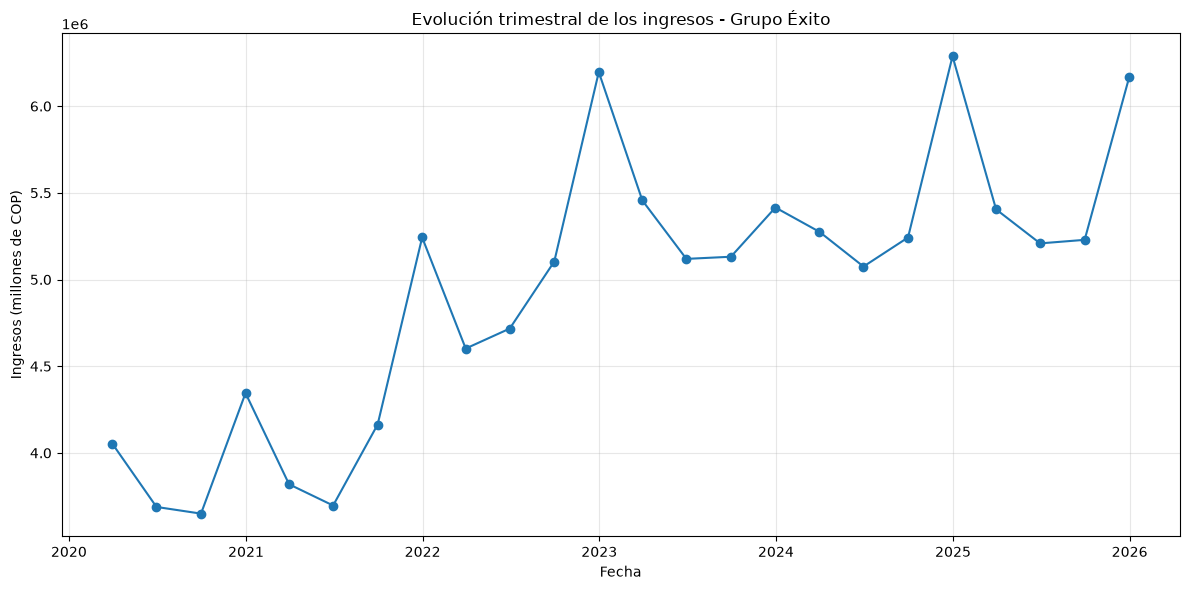

In [14]:
# Gráfica de ingresos trimestrales

plt.figure(figsize=(12, 6))

plt.plot(
    df_ts.index,
    df_ts["ingresos"],
    marker='o'
)

plt.title("Evolución trimestral de los ingresos - Grupo Éxito")
plt.xlabel("Fecha")
plt.ylabel("Ingresos (millones de COP)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

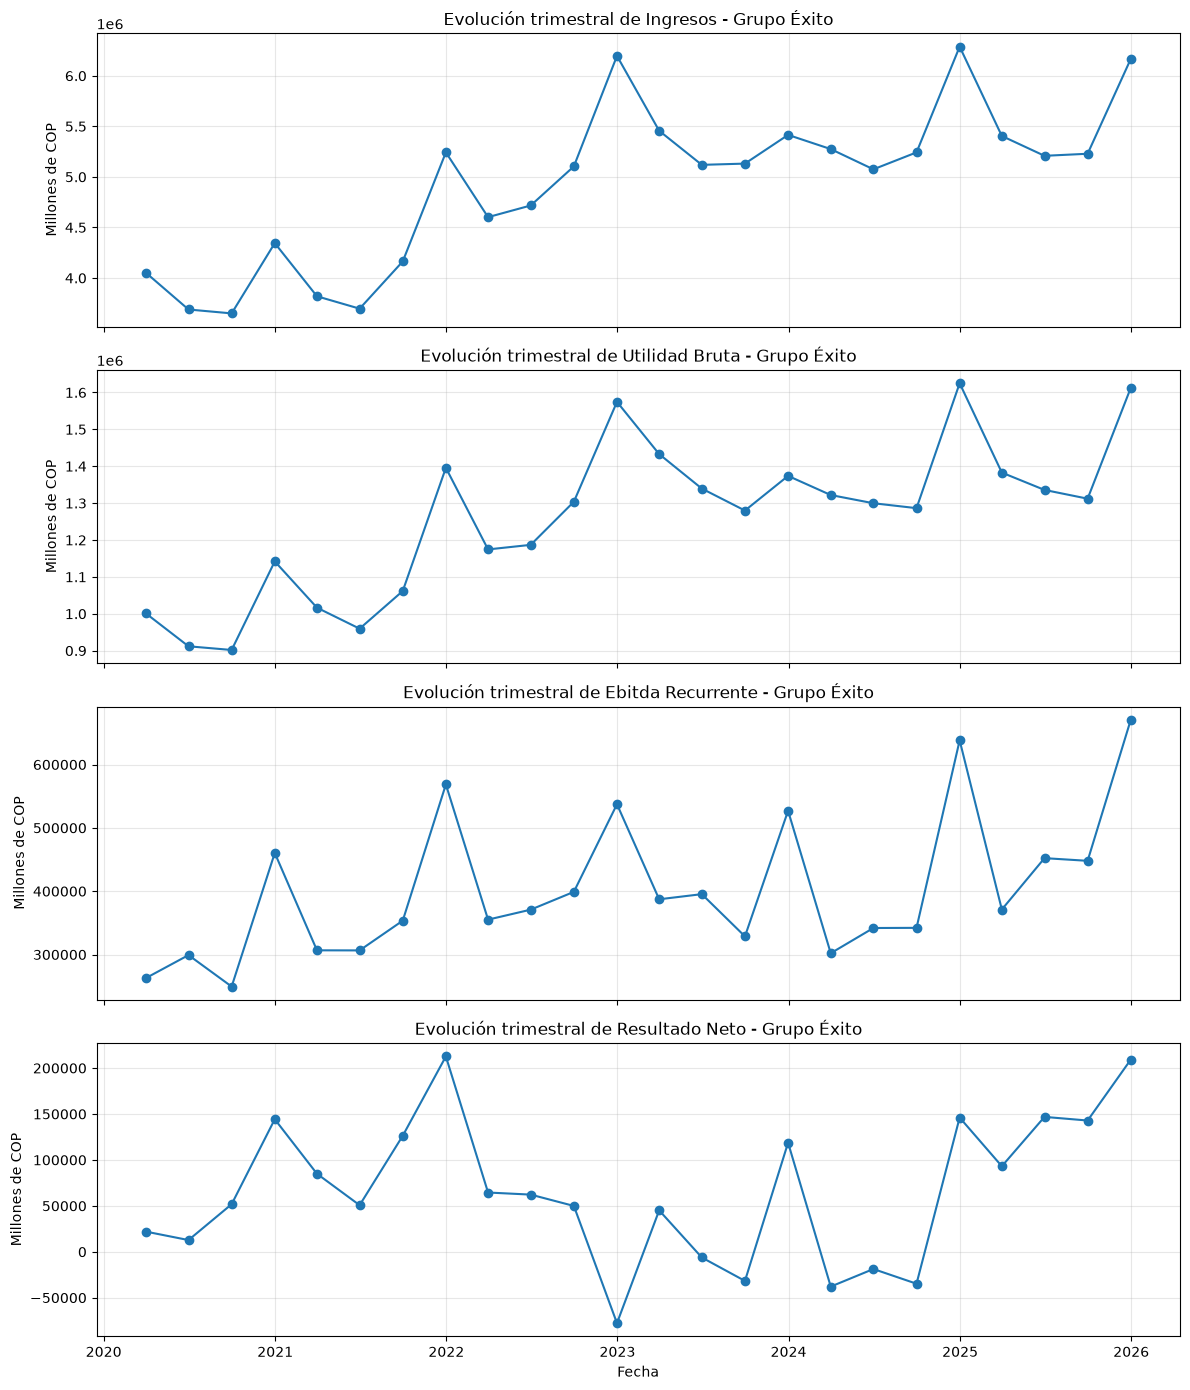

In [17]:
# Gráfica para identificar patrones visuales dentro de cada serie

fig, ax_list = plt.subplots(
    4, 1,
    figsize=(12, 14),
    sharex=True
)

for ax, variable in zip(ax_list, variables_financieras):
    
    ax.plot(
        df_ts.index,
        df_ts[variable],
        marker="o"
    )
    
    ax.set_title(
        f"Evolución trimestral de {variable.replace('_', ' ').title()} - Grupo Éxito"
    )
    
    ax.set_ylabel("Millones de COP")
    ax.grid(True, alpha=0.3)

ax_list[-1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()


In [18]:
# Evolución anual

df_anual = (
    df_ts.groupby("año")[variables_financieras].sum()
)

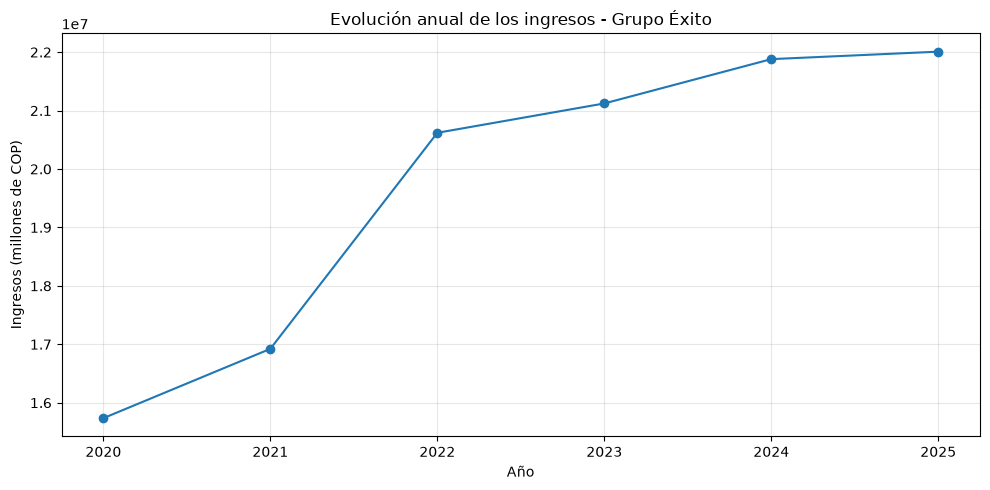

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_anual.index,
    df_anual["ingresos"],
    marker='o'
)

plt.title("Evolución anual de los ingresos - Grupo Éxito")
plt.xlabel("Año")
plt.ylabel("Ingresos (millones de COP)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [20]:
# Crecimiento anual de los ingresos

df_anual["crecimiento_ingresos_pct"] = (
    df_anual["ingresos"].pct_change() * 100
)

df_anual[
    ["ingresos", "crecimiento_ingresos_pct"]
].round(2)

,ingresos,crecimiento_ingresos_pct
año,,
2020,15735839,NaN
2021,16922385,7.54
2022,20619673,21.85
2023,21122087,2.44
2024,21880509,3.59
2025,22008360,0.58


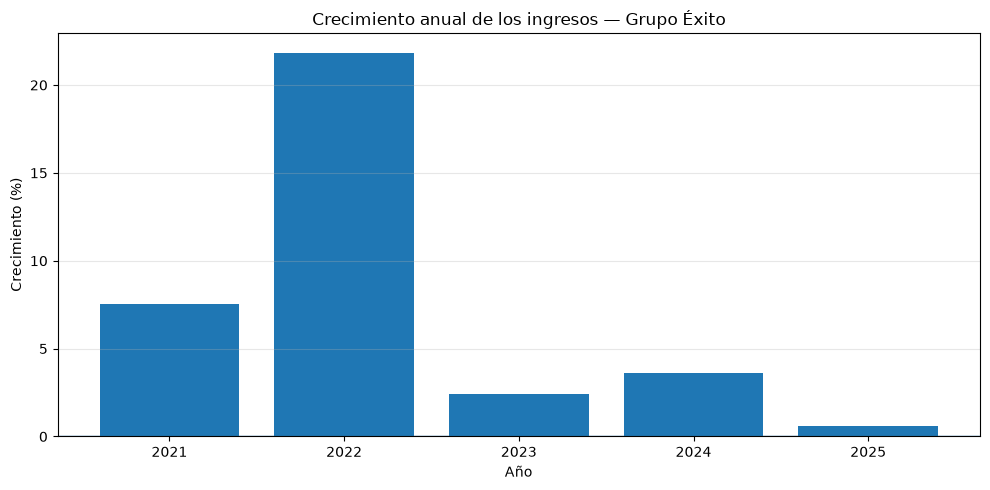

In [21]:
plt.figure(figsize=(10, 5))

plt.bar(
    df_anual.index,
    df_anual["crecimiento_ingresos_pct"]
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title("Crecimiento anual de los ingresos — Grupo Éxito")
plt.xlabel("Año")
plt.ylabel("Crecimiento (%)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Los ingresos presentan una tendencia creciente durante 2020–2025, pero con una desaceleración considerable después del fuerte crecimiento registrado en 2022. En 2025 se observa prácticamente una estabilización del nivel anual de ingresos.

### 3. Análisis de estacionalidad

In [22]:
# Comparación de ingresos por trimestre

ingresos_trimestrales = (
    df_financiero.groupby("trimestre")["ingresos"]
    .agg(["mean", "median", "min", "max"])
)
ingresos_trimestrales.round(2)

,mean,median,min,max
trimestre,,,,
1,4768250.83,4938553.0,3819172,5456154
2,4584144.00,4896066.0,3688456,5208469
3,4753408.67,5117661.0,3649939,5242429
4,5609005.33,5790840.0,4345013,6288024


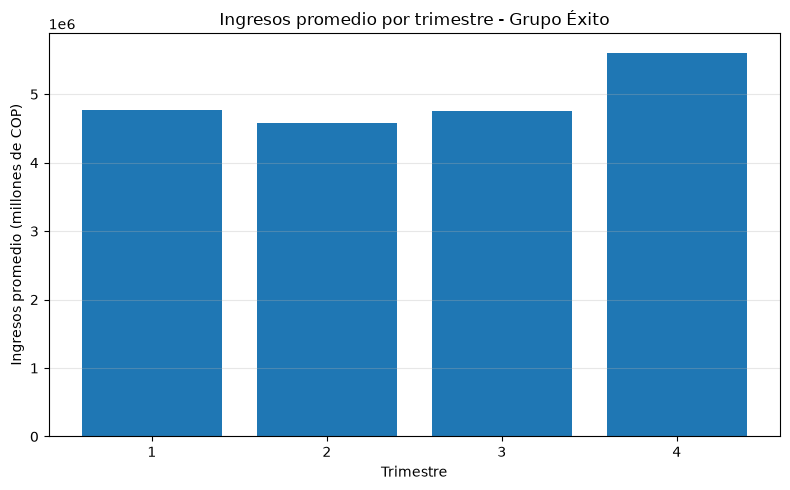

In [23]:
# gráfica de ingresos promedio por trimestre

plt.figure(figsize=(8, 5))

plt.bar(
    ingresos_trimestrales.index.astype(str),
    ingresos_trimestrales["mean"]
)

plt.title("Ingresos promedio por trimestre - Grupo Éxito")
plt.xlabel("Trimestre")
plt.ylabel("Ingresos promedio (millones de COP)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


### Estacionalidad trimestral de los ingresos

El análisis de los ingresos promedio por trimestre evidencia un patrón
estacional durante el período 2020–2025.

El cuarto trimestre presenta el mayor ingreso promedio, con aproximadamente
5,61 billones de COP, mientras que el segundo trimestre presenta el menor,
con aproximadamente 4,58 billones de COP.

El ingreso promedio del cuarto trimestre es aproximadamente 22,4 % superior
al del segundo trimestre. Los trimestres primero y tercero presentan niveles
promedio similares.

Este comportamiento constituye evidencia exploratoria de un patrón
estacional trimestral que deberá ser considerado posteriormente durante la
construcción y evaluación de los modelos de pronóstico.

In [24]:
ingresos_por_trimestre = df_financiero.pivot(
    index="año",
    columns="trimestre",
    values="ingresos"
)

ingresos_por_trimestre

trimestre,1,2,3,4
año,,,,
2020,4052431,3688456,3649939,4345013
2021,3819172,3696687,4163857,5242669
2022,4601967,4717215,5103845,6196646
2023,5456154,5119120,5131477,5415336
2024,5275139,5074917,5242429,6288024
2025,5404642,5208469,5228905,6166344


In [26]:
# Indice estacional por trimestre

promedio_general = df_financiero["ingresos"].mean()

indice_estacional = (
    ingresos_trimestrales["mean"] / promedio_general
) * 100

indice_estacional.round(2)

trimestre
1     96.74
2     93.01
3     96.44
4    113.80
Name: mean, dtype: float64

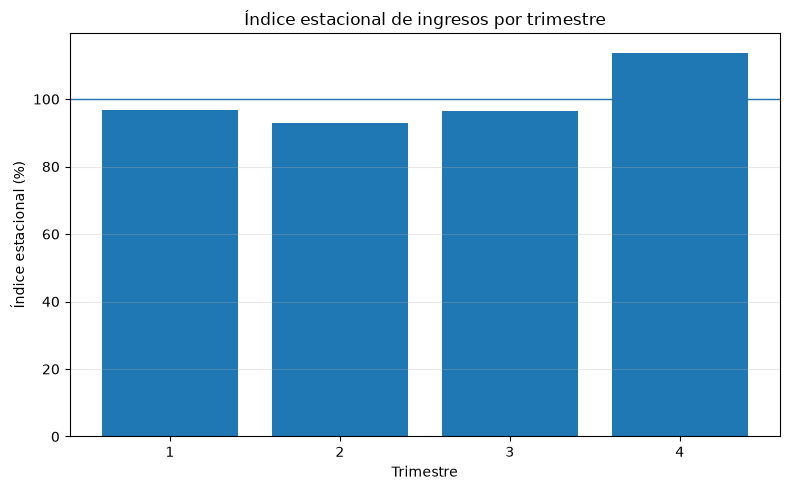

In [27]:
plt.figure(figsize=(8, 5))

plt.bar(
    indice_estacional.index.astype(str),
    indice_estacional.values
)

plt.axhline(
    100,
    linewidth=1
)

plt.title("Índice estacional de ingresos por trimestre")
plt.xlabel("Trimestre")
plt.ylabel("Índice estacional (%)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Índice estacional de los ingresos

El índice estacional trimestral muestra diferencias sistemáticas en el
nivel de ingresos durante el período 2020–2025.

El segundo trimestre presenta el menor índice estacional, con 93,01 %,
mientras que el cuarto trimestre alcanza 113,80 % respecto al promedio
general de la serie. Los trimestres primero y tercero presentan valores
cercanos al promedio, con 96,74 % y 96,44 %, respectivamente.

Estos resultados respaldan la existencia de un patrón estacional
trimestral en los ingresos. En particular, el cuarto trimestre presenta
un nivel de ingresos considerablemente superior al promedio, mientras que
el segundo trimestre presenta un nivel inferior.

La estacionalidad trimestral deberá ser considerada posteriormente en la
construcción y evaluación de los modelos de pronóstico.

In [29]:
def calcular_indice_estacional(df, variable):
    
    promedio_general = df[variable].mean()
    
    promedio_trimestre = (
        df.groupby("trimestre")[variable]
        .mean()
    )
    
    indice = (
        promedio_trimestre / promedio_general
    ) * 100
    
    return indice

In [30]:
for variable in variables_financieras:
    
    indice = calcular_indice_estacional(
        df_financiero,
        variable
    )
    
    print(f"\n{variable}")
    print(indice.round(2))


ingresos
trimestre
1     96.74
2     93.01
3     96.44
4    113.80
Name: ingresos, dtype: float64

utilidad_bruta
trimestre
1     96.98
2     93.06
3     94.54
4    115.42
Name: utilidad_bruta, dtype: float64

ebitda_recurrente
trimestre
1     82.08
2     89.56
3     87.69
4    140.67
Name: ebitda_recurrente, dtype: float64

resultado_neto
trimestre
1     68.94
2     62.82
3     77.22
4    191.02
Name: resultado_neto, dtype: float64


### Estacionalidad trimestral de las variables financieras

El análisis de los índices estacionales muestra que las cuatro variables financieras presentan patrones trimestrales diferenciados.

Los ingresos y la utilidad bruta presentan una estacionalidad moderada, con niveles inferiores al promedio principalmente en T2 y niveles superiores al promedio en T4. Sus índices estacionales de T4 alcanzan 113,80 % y 115,42 %, respectivamente.

El EBITDA recurrente presenta una estacionalidad más pronunciada. Mientras T1, T2 y T3 se encuentran por debajo del promedio, T4 alcanza un índice de 140,67 %, evidenciando una concentración importante del resultado operativo recurrente durante este trimestre.

El resultado neto presenta la mayor amplitud estacional de las variables analizadas. T1, T2 y T3 se encuentran por debajo del promedio, con índices de 68,94 %, 62,82 % y 77,22 %, respectivamente, mientras que T4 alcanza 191,02 %.

Estos resultados indican que la estacionalidad debe ser considerada de forma específica para cada variable durante la construcción y evaluación de los modelos de pronóstico. En particular, el comportamiento del resultado neto no debe extrapolarse directamente a partir del patrón observado en los ingresos.

### 4. Variación interanual

Comparación de cada trimestre con el mismo trimestre del año anterior.

In [32]:
variables_financieras = [
    "ingresos",
    "utilidad_bruta",
    "ebitda_recurrente",
    "resultado_neto"
]

for variable in variables_financieras:
    df_ts[f"{variable}_yoy_pct"] = (
        df_ts[variable].pct_change(4) * 100
    )

In [34]:
columnas_yoy = [
    f"{variable}_yoy_pct"
    for variable in variables_financieras
]

df_yoy = df_ts[columnas_yoy].copy()

df_yoy.round(2)

,ingresos_yoy_pct,utilidad_bruta_yoy_pct,ebitda_recurrente_yoy_pct,resultado_neto_yoy_pct
fecha,,,,
2020-03-31,NaN,NaN,NaN,NaN
2020-06-30,NaN,NaN,NaN,NaN
2020-09-30,NaN,NaN,NaN,NaN
2020-12-31,NaN,NaN,NaN,NaN
2021-03-31,-5.76,1.54,16.69,286.40
2021-06-30,0.22,5.24,2.48,296.84
2021-09-30,14.08,17.72,41.71,143.79
2021-12-31,20.66,22.21,23.50,47.39
2022-03-31,20.50,15.54,15.80,-24.03


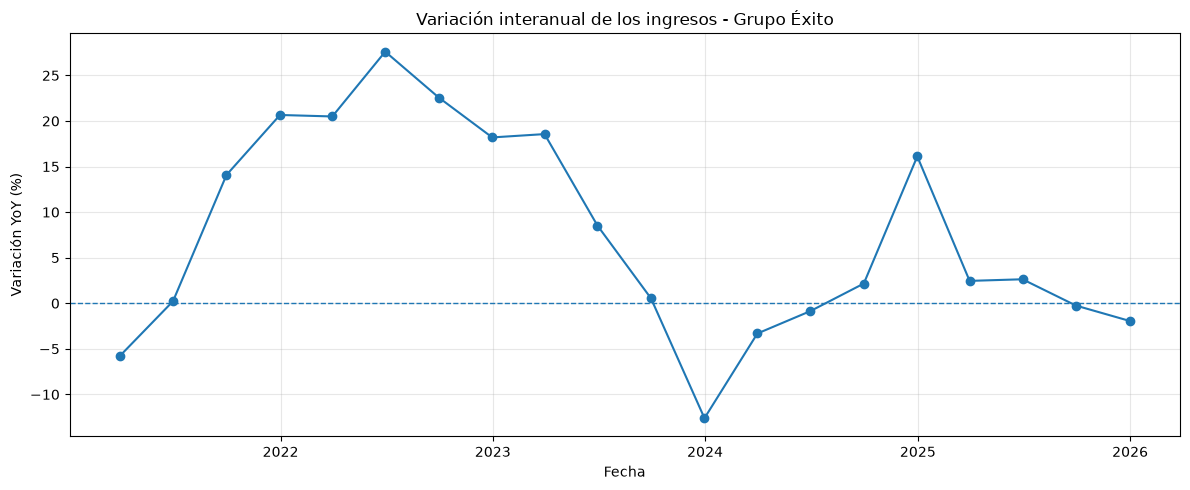

In [ ]:
# Grafico de crecimiento interanual de los ingresos

plt.figure(figsize=(12, 5))

plt.plot(
    df_ts.index,
    df_ts["ingresos_yoy_pct"],
    marker="o"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Variación interanual de los ingresos - Grupo Éxito"
)

plt.xlabel("Fecha")
plt.ylabel("Variación YoY (%)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

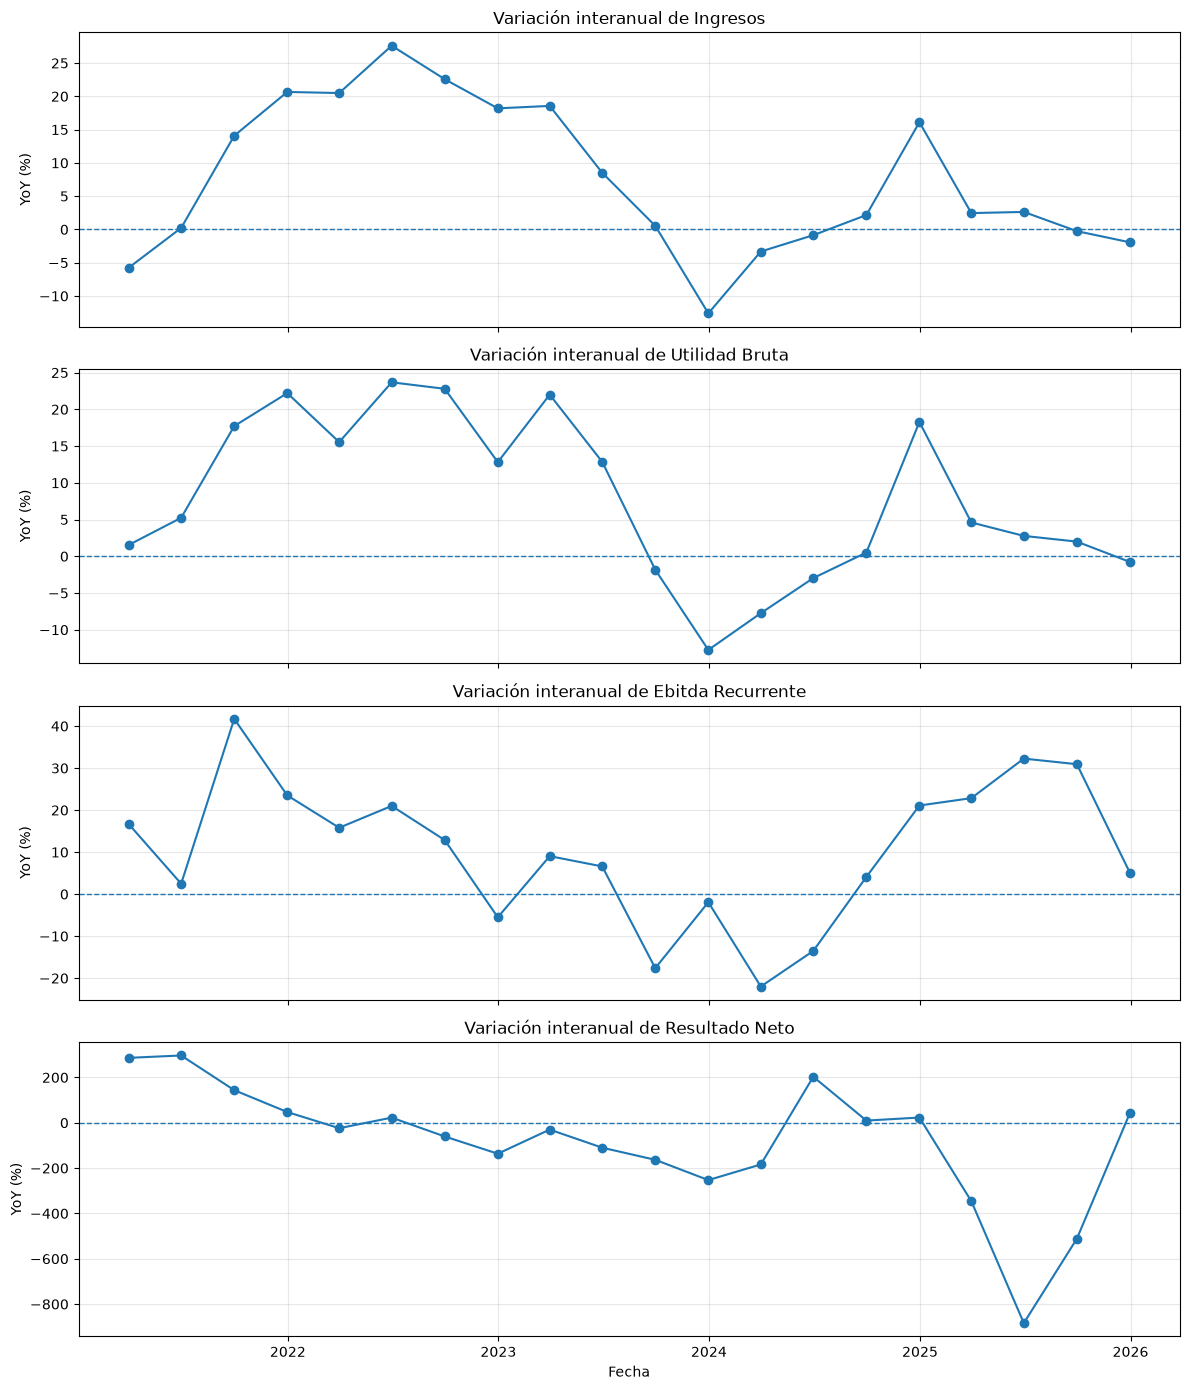

In [36]:
fig, ax_list = plt.subplots(
    4, 1,
    figsize=(12, 14),
    sharex=True
)

for ax, variable in zip(ax_list, variables_financieras):

    ax.plot(
        df_ts.index,
        df_ts[f"{variable}_yoy_pct"],
        marker="o"
    )

    ax.axhline(
        y=0,
        linestyle="--",
        linewidth=1
    )

    ax.set_title(
        f"Variación interanual de {variable.replace('_', ' ').title()}"
    )

    ax.set_ylabel("YoY (%)")
    ax.grid(True, alpha=0.3)

ax_list[-1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

### 5. variación trimestral

Comparación de cada trimestre con el trimestre inmediatamente anterior.

In [37]:
for variable in variables_financieras:
    df_ts[f"{variable}_qoq_pct"] = (
        df_ts[variable].pct_change(1) * 100
    )

In [38]:
columnas_qoq = [
    f"{variable}_qoq_pct"
    for variable in variables_financieras
]

df_qoq = df_ts[columnas_qoq].copy()

df_qoq.round(2)

,ingresos_qoq_pct,utilidad_bruta_qoq_pct,ebitda_recurrente_qoq_pct,resultado_neto_qoq_pct
fecha,,,,
2020-03-31,NaN,NaN,NaN,NaN
2020-06-30,-8.98,-8.91,13.82,-41.84
2020-09-30,-1.04,-1.10,-16.61,305.21
2020-12-31,19.04,26.63,84.57,178.47
2021-03-31,-12.10,-10.99,-33.39,-41.12
2021-06-30,-3.21,-5.60,-0.04,-40.27
2021-09-30,12.64,10.63,15.32,148.93
2021-12-31,25.91,31.46,60.85,68.36
2022-03-31,-12.22,-15.85,-37.54,-69.65


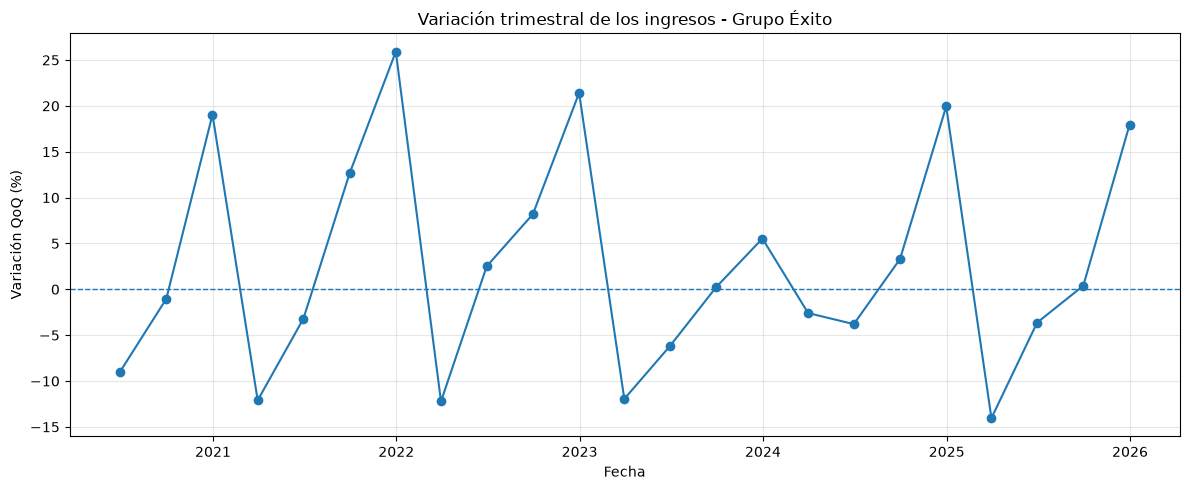

In [39]:
# Gráfico QoQ de los ingresos

plt.figure(figsize=(12, 5))

plt.plot(
    df_ts.index,
    df_ts["ingresos_qoq_pct"],
    marker="o"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Variación trimestral de los ingresos - Grupo Éxito"
)

plt.xlabel("Fecha")
plt.ylabel("Variación QoQ (%)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
# Tabla de crecimiento interanual y trimestral de los ingresos

df_variaciones = df_ts[
    [
        "ingresos_yoy_pct",
        "ingresos_qoq_pct",
        "utilidad_bruta_yoy_pct",
        "utilidad_bruta_qoq_pct",
        "ebitda_recurrente_yoy_pct",
        "ebitda_recurrente_qoq_pct",
        "resultado_neto_yoy_pct",
        "resultado_neto_qoq_pct"
    ]
].copy()

df_variaciones.round(2)

df_variaciones = df_variaciones.reset_index()

df_variaciones["periodo"] = (
    df_variaciones["fecha"].dt.year.astype(str)
    + "-T"
    + df_variaciones["fecha"].dt.quarter.astype(str)
)

df_variaciones = df_variaciones[
    [
        "periodo",
        "ingresos_yoy_pct",
        "ingresos_qoq_pct",
        "utilidad_bruta_yoy_pct",
        "utilidad_bruta_qoq_pct",
        "ebitda_recurrente_yoy_pct",
        "ebitda_recurrente_qoq_pct",
        "resultado_neto_yoy_pct",
        "resultado_neto_qoq_pct"
    ]
]

df_variaciones.round(2)

,periodo,ingresos_yoy_pct,ingresos_qoq_pct,utilidad_bruta_yoy_pct,utilidad_bruta_qoq_pct,ebitda_recurrente_yoy_pct,ebitda_recurrente_qoq_pct,resultado_neto_yoy_pct,resultado_neto_qoq_pct
0,2020-T1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-T2,NaN,-8.98,NaN,-8.91,NaN,13.82,NaN,-41.84
2,2020-T3,NaN,-1.04,NaN,-1.10,NaN,-16.61,NaN,305.21
3,2020-T4,NaN,19.04,NaN,26.63,NaN,84.57,NaN,178.47
4,2021-T1,-5.76,-12.10,1.54,-10.99,16.69,-33.39,286.40,-41.12
5,2021-T2,0.22,-3.21,5.24,-5.60,2.48,-0.04,296.84,-40.27
6,2021-T3,14.08,12.64,17.72,10.63,41.71,15.32,143.79,148.93
7,2021-T4,20.66,25.91,22.21,31.46,23.50,60.85,47.39,68.36
8,2022-T1,20.50,-12.22,15.54,-15.85,15.80,-37.54,-24.03,-69.65
9,2022-T2,27.61,2.50,23.68,1.05,20.99,4.44,22.70,-3.53


El análisis de las variaciones interanuales evidencia un período de fuerte crecimiento durante 2022, seguido de una desaceleración durante 2023 y una leve recuperación desde 2024 en adelante. Las variaciones trimestrales muestran una marcada influencia de la estacionalidad, especialmente asociada al comportamiento del cuarto trimestre. Mientras los ingresos y la utilidad bruta presentan patrones relativamente similares, el EBITDA recurrente y, especialmente, el resultado neto muestran una mayor volatilidad. Por esta razón, las variaciones YoY y QoQ deberán utilizarse como variables descriptivas y de diagnóstico, considerando particularmente la estacionalidad y el comportamiento del resultado neto

### 6. Anaálisis de tendencia y cambios estructurales (margenes)


In [45]:
# Cálculo de márgenes financieros trimestrales

df_ts["margen_bruto_pct"] = (
    df_ts["utilidad_bruta"] / df_ts["ingresos"]
) * 100

df_ts["margen_ebitda_pct"] = (
    df_ts["ebitda_recurrente"] / df_ts["ingresos"]
) * 100

df_ts["margen_neto_pct"] = (
    df_ts["resultado_neto"] / df_ts["ingresos"]
) * 100


df_margenes = df_ts[
    [
        "margen_bruto_pct",
        "margen_ebitda_pct",
        "margen_neto_pct"
    ]
].copy()

df_margenes.round(2)

,margen_bruto_pct,margen_ebitda_pct,margen_neto_pct
fecha,,,
2020-03-31,24.70,6.49,0.54
2020-06-30,24.72,8.11,0.35
2020-09-30,24.71,6.83,1.42
2020-12-31,26.28,10.60,3.32
2021-03-31,26.62,8.03,2.22
2021-06-30,25.96,8.29,1.37
2021-09-30,25.50,8.49,3.03
2021-12-31,26.62,10.85,4.06
2022-03-31,25.52,7.72,1.40


In [46]:
df_margenes = df_margenes.reset_index()

df_margenes["periodo"] = (
    df_margenes["fecha"].dt.year.astype(str)
    + "-T"
    + df_margenes["fecha"].dt.quarter.astype(str)
)

df_margenes = df_margenes[
    [
        "periodo",
        "margen_bruto_pct",
        "margen_ebitda_pct",
        "margen_neto_pct"
    ]
]

df_margenes.round(2)

,periodo,margen_bruto_pct,margen_ebitda_pct,margen_neto_pct
0,2020-T1,24.70,6.49,0.54
1,2020-T2,24.72,8.11,0.35
2,2020-T3,24.71,6.83,1.42
3,2020-T4,26.28,10.60,3.32
4,2021-T1,26.62,8.03,2.22
5,2021-T2,25.96,8.29,1.37
6,2021-T3,25.50,8.49,3.03
7,2021-T4,26.62,10.85,4.06
8,2022-T1,25.52,7.72,1.40
9,2022-T2,25.16,7.86,1.32


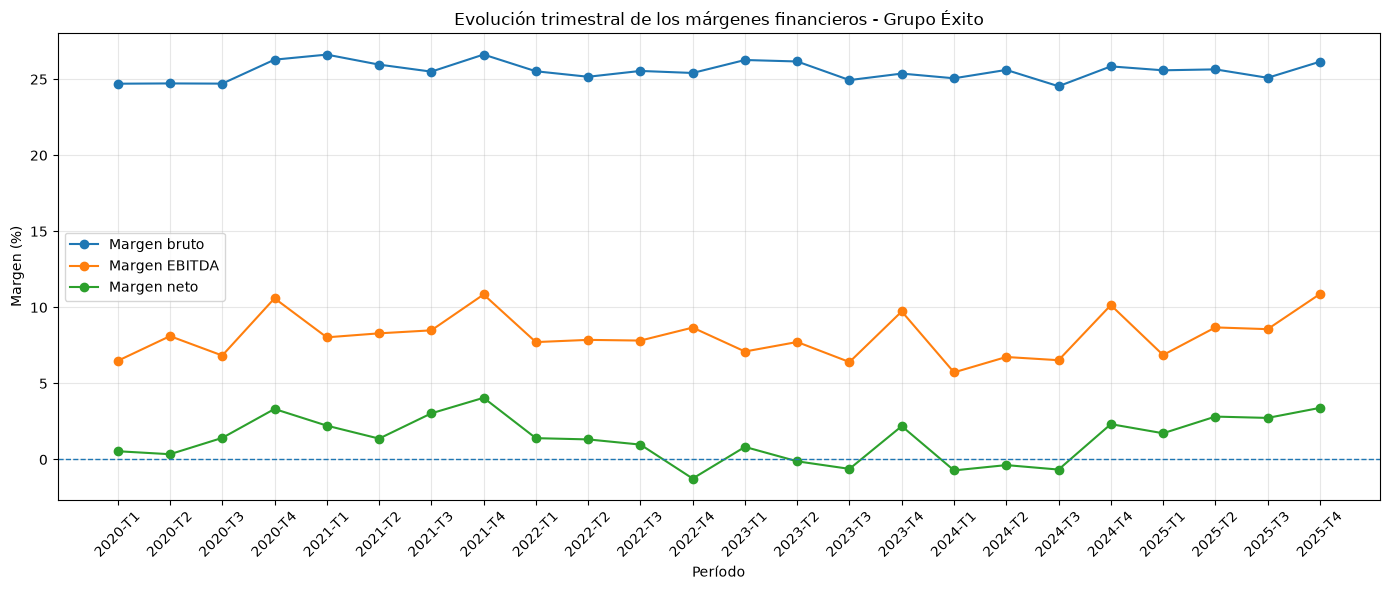

In [47]:
# Gráfico de evolución trimestral de los márgenes financieros

plt.figure(figsize=(14, 6))

plt.plot(
    df_margenes["periodo"],
    df_margenes["margen_bruto_pct"],
    marker="o",
    label="Margen bruto"
)

plt.plot(
    df_margenes["periodo"],
    df_margenes["margen_ebitda_pct"],
    marker="o",
    label="Margen EBITDA"
)

plt.plot(
    df_margenes["periodo"],
    df_margenes["margen_neto_pct"],
    marker="o",
    label="Margen neto"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Evolución trimestral de los márgenes financieros - Grupo Éxito"
)

plt.xlabel("Período")
plt.ylabel("Margen (%)")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
# Margenes promedio por trimestre

margenes_trimestre = (
    df_ts
    .groupby(df_ts.index.quarter)[
        [
            "margen_bruto_pct",
            "margen_ebitda_pct",
            "margen_neto_pct"
        ]
    ]
    .mean()
)

margenes_trimestre.index = [
    "T1", "T2", "T3", "T4"
]

margenes_trimestre.round(2)

,margen_bruto_pct,margen_ebitda_pct,margen_neto_pct
T1,25.62,6.99,1.00
T2,25.54,7.90,0.89
T3,25.05,7.44,1.15
T4,25.95,10.15,2.34


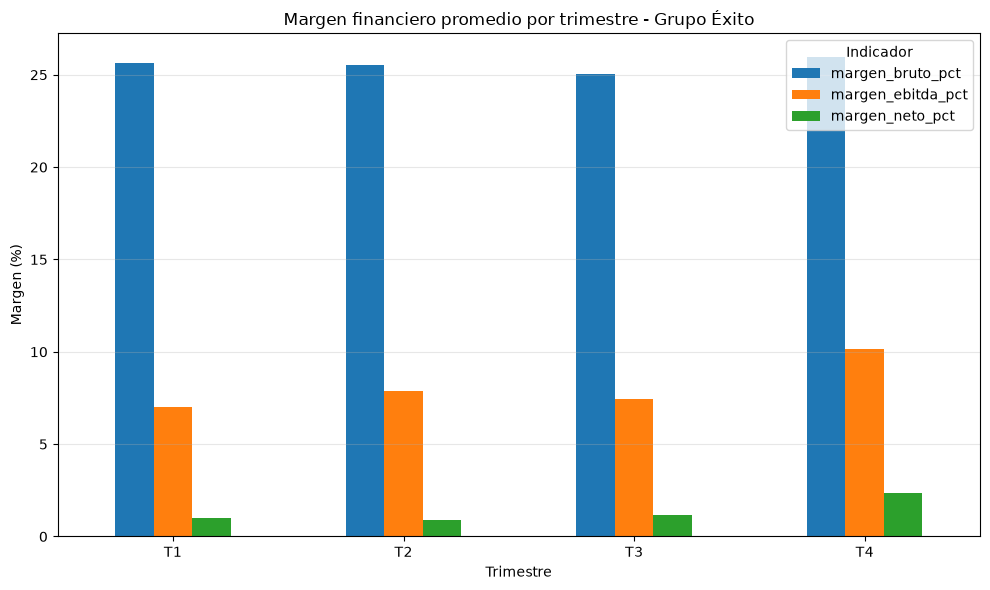

In [49]:
margenes_trimestre.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Margen financiero promedio por trimestre - Grupo Éxito"
)

plt.xlabel("Trimestre")
plt.ylabel("Margen (%)")

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend(
    title="Indicador"
)

plt.tight_layout()
plt.show()

In [50]:
# Desviación estandar trimestral

volatilidad_margenes = df_ts[
    [
        "margen_bruto_pct",
        "margen_ebitda_pct",
        "margen_neto_pct"
    ]
].std()

volatilidad_margenes.round(2)

margen_bruto_pct     0.61
margen_ebitda_pct    1.47
margen_neto_pct      1.49
dtype: float64

### Análisis de márgenes financieros trimestrales

El análisis de los márgenes financieros muestra comportamientos diferenciados entre las variables. El margen bruto presenta una variabilidad relativamente baja durante el período 2020–2025, con una desviación estándar de 0,61 puntos porcentuales y valores promedio trimestrales cercanos al 25 %. Esto indica una relación relativamente estable entre la utilidad bruta y los ingresos.

El margen EBITDA presenta una mayor variabilidad, con una desviación estándar de 1,47 puntos porcentuales. Además, se observa un comportamiento estacional más marcado, con un margen promedio de 10,15 % en T4 frente a 6,99 % en T1.

El margen neto presenta una variabilidad similar a la del EBITDA, con una desviación estándar de 1,49 puntos porcentuales. A diferencia del margen bruto y del EBITDA, registra períodos con márgenes negativos, especialmente entre 2022-T4 y 2024-T3. Posteriormente se observa una recuperación durante 2024-T4 y 2025, alcanzando un margen neto de 3,39 % en 2025-T4.

En conjunto, los resultados muestran que la rentabilidad bruta es relativamente estable, mientras que los márgenes EBITDA y neto presentan una mayor sensibilidad a las variaciones trimestrales y a la estacionalidad. Esta diferenciación deberá considerarse posteriormente durante la construcción de variables y el desarrollo de los modelos de pronóstico.

### 7. Correlaciones y gráficos de dispersión

In [51]:
# Matriz de correlación

variables_correlacion = [
    "ingresos",
    "utilidad_bruta",
    "ebitda_recurrente",
    "resultado_neto"
]

matriz_correlacion = df_ts[
    variables_correlacion
].corr()

matriz_correlacion.round(3)

,ingresos,utilidad_bruta,ebitda_recurrente,resultado_neto
ingresos,1.000,0.991,0.759,0.096
utilidad_bruta,0.991,1.000,0.802,0.169
ebitda_recurrente,0.759,0.802,1.000,0.581
resultado_neto,0.096,0.169,0.581,1.000


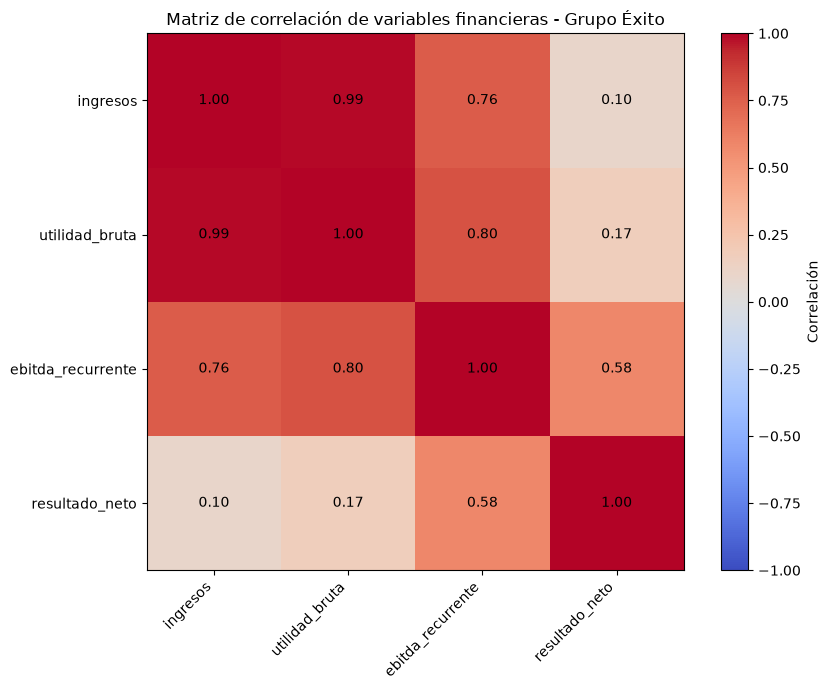

In [57]:
plt.figure(figsize=(9, 7))

plt.imshow(
    matriz_correlacion,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlación")

plt.xticks(
    range(len(matriz_correlacion.columns)),
    matriz_correlacion.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(matriz_correlacion.index)),
    matriz_correlacion.index
)

# Mostrar los valores dentro de cada celda
for i in range(len(matriz_correlacion.index)):
    for j in range(len(matriz_correlacion.columns)):
        plt.text(
            j,
            i,
            f"{matriz_correlacion.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Matriz de correlación de variables financieras - Grupo Éxito")
plt.tight_layout()
plt.show()

### Análisis de correlación entre variables financieras

La matriz de correlación muestra una relación positiva muy fuerte entre los ingresos y la utilidad bruta, con un coeficiente de Pearson de 0,99. Esto indica que ambas variables presentan un comportamiento muy similar durante el período analizado.

Los ingresos también presentan una correlación positiva fuerte con el EBITDA recurrente (0,76), mientras que la utilidad bruta y el EBITDA recurrente presentan una correlación de 0,80. Estas relaciones son consistentes con la relación existente entre el nivel de actividad de la empresa y su generación de resultados operativos.

En contraste, la correlación entre los ingresos y el resultado neto es muy baja (0,10), al igual que la relación entre la utilidad bruta y el resultado neto (0,17). Esto evidencia que el resultado neto presenta un comportamiento más independiente y volátil frente a las variables asociadas directamente con los ingresos.

El EBITDA recurrente presenta una correlación moderada con el resultado neto (0,58), lo que indica una relación positiva, aunque no determinante.

En términos de modelamiento, estos resultados permiten identificar posibles relaciones entre las variables financieras y, al mismo tiempo, alertan sobre la alta similitud entre ingresos y utilidad bruta. Sin embargo, debido a que el conjunto contiene únicamente 24 observaciones trimestrales, las correlaciones deben interpretarse como evidencia descriptiva y no como evidencia de causalidad o capacidad predictiva.

Gráficos de dispersión

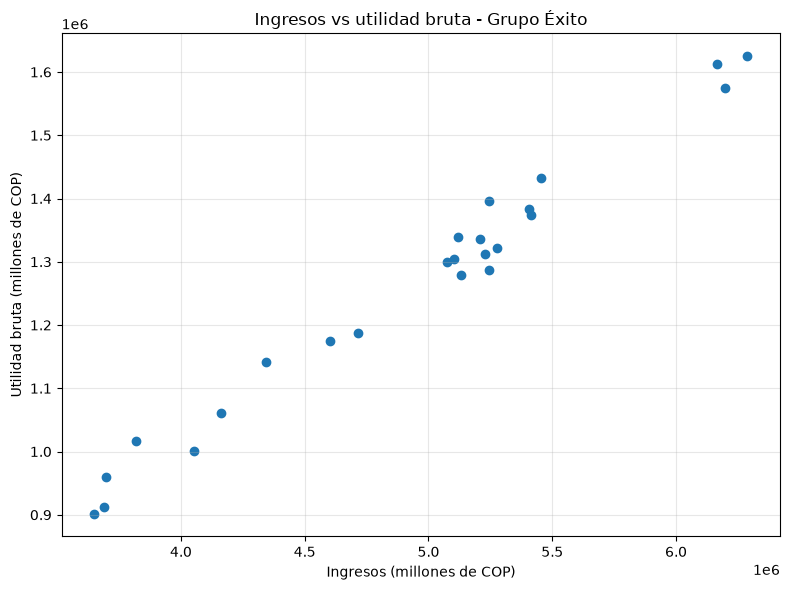

In [ ]:
# Relación entre ingresos y utilidad bruta

plt.figure(figsize=(8, 6))

plt.scatter(
    df_ts["ingresos"],
    df_ts["utilidad_bruta"]
)

plt.title(
    "Ingresos vs utilidad bruta - Grupo Éxito"
)

plt.xlabel("Ingresos (millones de COP)")
plt.ylabel("Utilidad bruta (millones de COP)")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Se presenta un comportamiento lineal positivo, lo que indica que en la mayoria de los casos el aumento de los ingresos afecta directamente  y en una medida similar el incremento de la utilidad bruta.

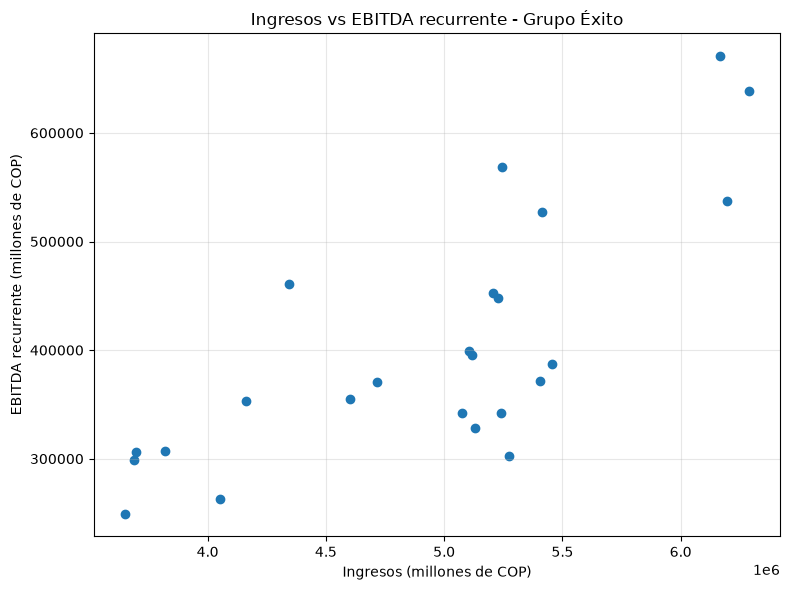

In [60]:
# Relación entre ingresos y EBITDA recurrente

plt.figure(figsize=(8, 6))

plt.scatter(
    df_ts["ingresos"],
    df_ts["ebitda_recurrente"]
)

plt.title(
    "Ingresos vs EBITDA recurrente - Grupo Éxito"
)

plt.xlabel("Ingresos (millones de COP)")
plt.ylabel("EBITDA recurrente (millones de COP)")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Se observa una relación positiva entre los ingresos y el EBITDA recurrente, sin embargo, no se puede determinar algun tipo de tendencia, lo que nos indica que los ingresos presentan un pequeño impacto en el comportamiento que tomará el EBITDA trimestre a tirmeste.

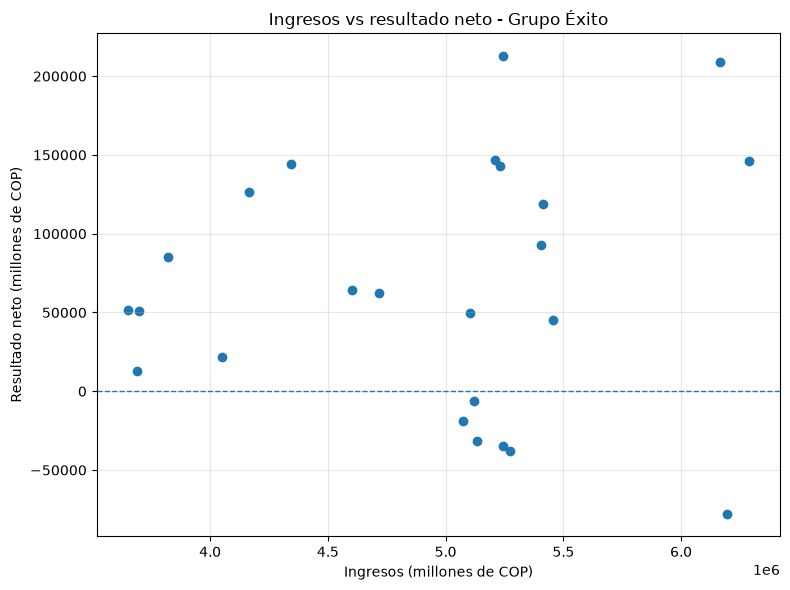

In [61]:
# Relación entre ingresos y resultado neto

plt.figure(figsize=(8, 6))

plt.scatter(
    df_ts["ingresos"],
    df_ts["resultado_neto"]
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Ingresos vs resultado neto - Grupo Éxito"
)

plt.xlabel("Ingresos (millones de COP)")
plt.ylabel("Resultado neto (millones de COP)")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Se evidencia que el impacto que tienen los ingresos en la determinación del resultado neto es practicamente nula, en donde al tener un mayor nivel de ingresos no va a garantizar que el resultado final sea de la misma porporción o almenos que este sea positivo

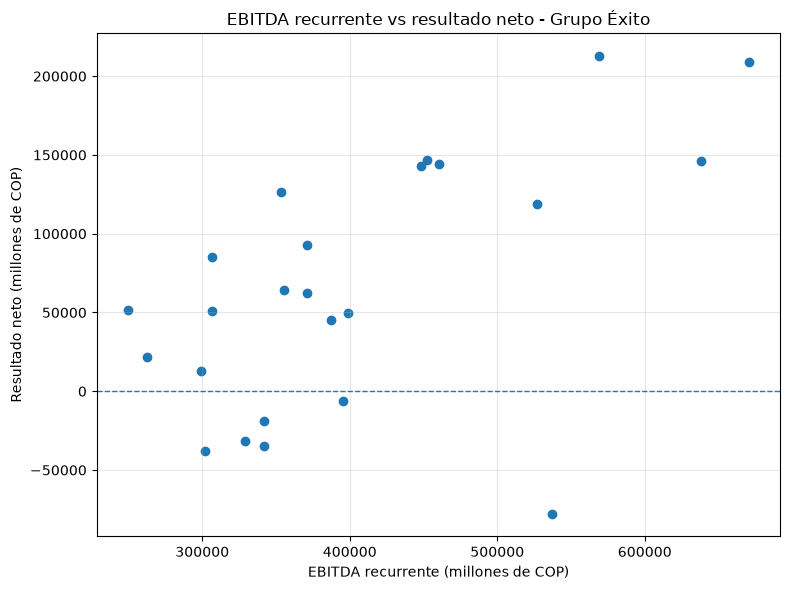

In [62]:
# Relación entre EBITDA recurrente y resultado neto

plt.figure(figsize=(8, 6))

plt.scatter(
    df_ts["ebitda_recurrente"],
    df_ts["resultado_neto"]
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "EBITDA recurrente vs resultado neto - Grupo Éxito"
)

plt.xlabel("EBITDA recurrente (millones de COP)")
plt.ylabel("Resultado neto (millones de COP)")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Se presenta una relación levemente positiva entre el EBITDA y el resultado neto, aunque no se evidencia algún tipo de tendencia, lo que permite garantizar que el comportamiento de estas dos variables no depende en gran parte una de la otra.

### Análisis de tendencia y volatilidad

In [63]:
df_tendencia = df_ts.copy()

df_tendencia = df_tendencia.sort_index()

df_tendencia.head()

,año,trimestre,ingresos,utilidad_bruta,ebitda_recurrente,resultado_neto,periodo,ingresos_yoy_pct,utilidad_bruta_yoy_pct,ebitda_recurrente_yoy_pct,resultado_neto_yoy_pct,ingresos_qoq_pct,utilidad_bruta_qoq_pct,ebitda_recurrente_qoq_pct,resultado_neto_qoq_pct,margen_bruto_pct,margen_ebitda_pct,margen_neto_pct
fecha,,,,,,,,,,,,,,,,,,
2020-03-31,2020,1,4052431,1001122,262832,21987,2020Q1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.704233,6.485786,0.542563
2020-06-30,2020,2,3688456,911875,299143,12787,2020Q2,NaN,NaN,NaN,NaN,-8.981646,-8.914698,13.815289,-41.842907,24.722404,8.110250,0.346676
2020-09-30,2020,3,3649939,901871,249457,51814,2020Q3,NaN,NaN,NaN,NaN,-1.044258,-1.097080,-16.609448,305.208415,24.709207,6.834553,1.419585
2020-12-31,2020,4,4345013,1142061,460429,144284,2020Q4,NaN,NaN,NaN,NaN,19.043442,26.632412,84.572491,178.465280,26.284409,10.596723,3.320681
2021-03-31,2021,1,3819172,1016535,306694,84957,2021Q1,-5.756026,1.539573,16.688227,286.396507,-12.102173,-10.991182,-33.389513,-41.118211,26.616633,8.030379,2.224487


In [64]:
estadisticos = df_tendencia[
    variables_financieras
].describe().T

estadisticos

,count,mean,std,min,25%,50%,75%,max
ingresos,24.0,4.928702e+06,783274.911880,3649939.0,4299724.00,5125298.5,5307514.75,6288024.0
utilidad_bruta,24.0,1.259672e+06,207229.360380,901871.0,1121965.25,1301692.5,1376062.75,1624970.0
ebitda_recurrente,24.0,4.031059e+05,113896.654294,249457.0,323205.25,371032.5,454288.75,670615.0
resultado_neto,24.0,6.572988e+04,79112.152678,-77668.0,8044.25,57039.0,130462.50,212665.0


In [65]:
estadisticos["coef_variacion_pct"] = (
    estadisticos["std"] /
    estadisticos["mean"]
) * 100

estadisticos.round(2)

,count,mean,std,min,25%,50%,75%,max,coef_variacion_pct
ingresos,24.0,4928702.21,783274.91,3649939.0,4299724.00,5125298.5,5307514.75,6288024.0,15.89
utilidad_bruta,24.0,1259672.17,207229.36,901871.0,1121965.25,1301692.5,1376062.75,1624970.0,16.45
ebitda_recurrente,24.0,403105.88,113896.65,249457.0,323205.25,371032.5,454288.75,670615.0,28.25
resultado_neto,24.0,65729.88,79112.15,-77668.0,8044.25,57039.0,130462.50,212665.0,120.36


In [66]:
# Media movil de 4 trimestres

for variable in variables_financieras:
    df_tendencia[f"{variable}_media_movil_4t"] = (
        df_tendencia[variable]
        .rolling(window=4)
        .mean()
    )

df_tendencia[
    [
        "ingresos",
        "ingresos_media_movil_4t",
        "utilidad_bruta",
        "utilidad_bruta_media_movil_4t",
        "ebitda_recurrente",
        "ebitda_recurrente_media_movil_4t",
        "resultado_neto",
        "resultado_neto_media_movil_4t"
    ]
].round(2)

,ingresos,ingresos_media_movil_4t,utilidad_bruta,utilidad_bruta_media_movil_4t,ebitda_recurrente,ebitda_recurrente_media_movil_4t,resultado_neto,resultado_neto_media_movil_4t
fecha,,,,,,,,
2020-03-31,4052431,NaN,1001122,NaN,262832,NaN,21987,NaN
2020-06-30,3688456,NaN,911875,NaN,299143,NaN,12787,NaN
2020-09-30,3649939,NaN,901871,NaN,249457,NaN,51814,NaN
2020-12-31,4345013,3933959.75,1142061,989232.25,460429,317965.25,144284,57718.00
2021-03-31,3819172,3875645.00,1016535,993085.50,306694,328930.75,84957,73460.50
2021-06-30,3696687,3877702.75,959633,1005025.00,306557,330784.25,50744,82949.75
2021-09-30,4163857,4006182.25,1061678,1044976.75,353514,356798.50,126315,101575.00
2021-12-31,5242669,4230596.25,1395683,1108382.25,568638,383850.75,212665,118670.25
2022-03-31,4601967,4426295.00,1174498,1147873.00,355163,395968.00,64539,113565.75


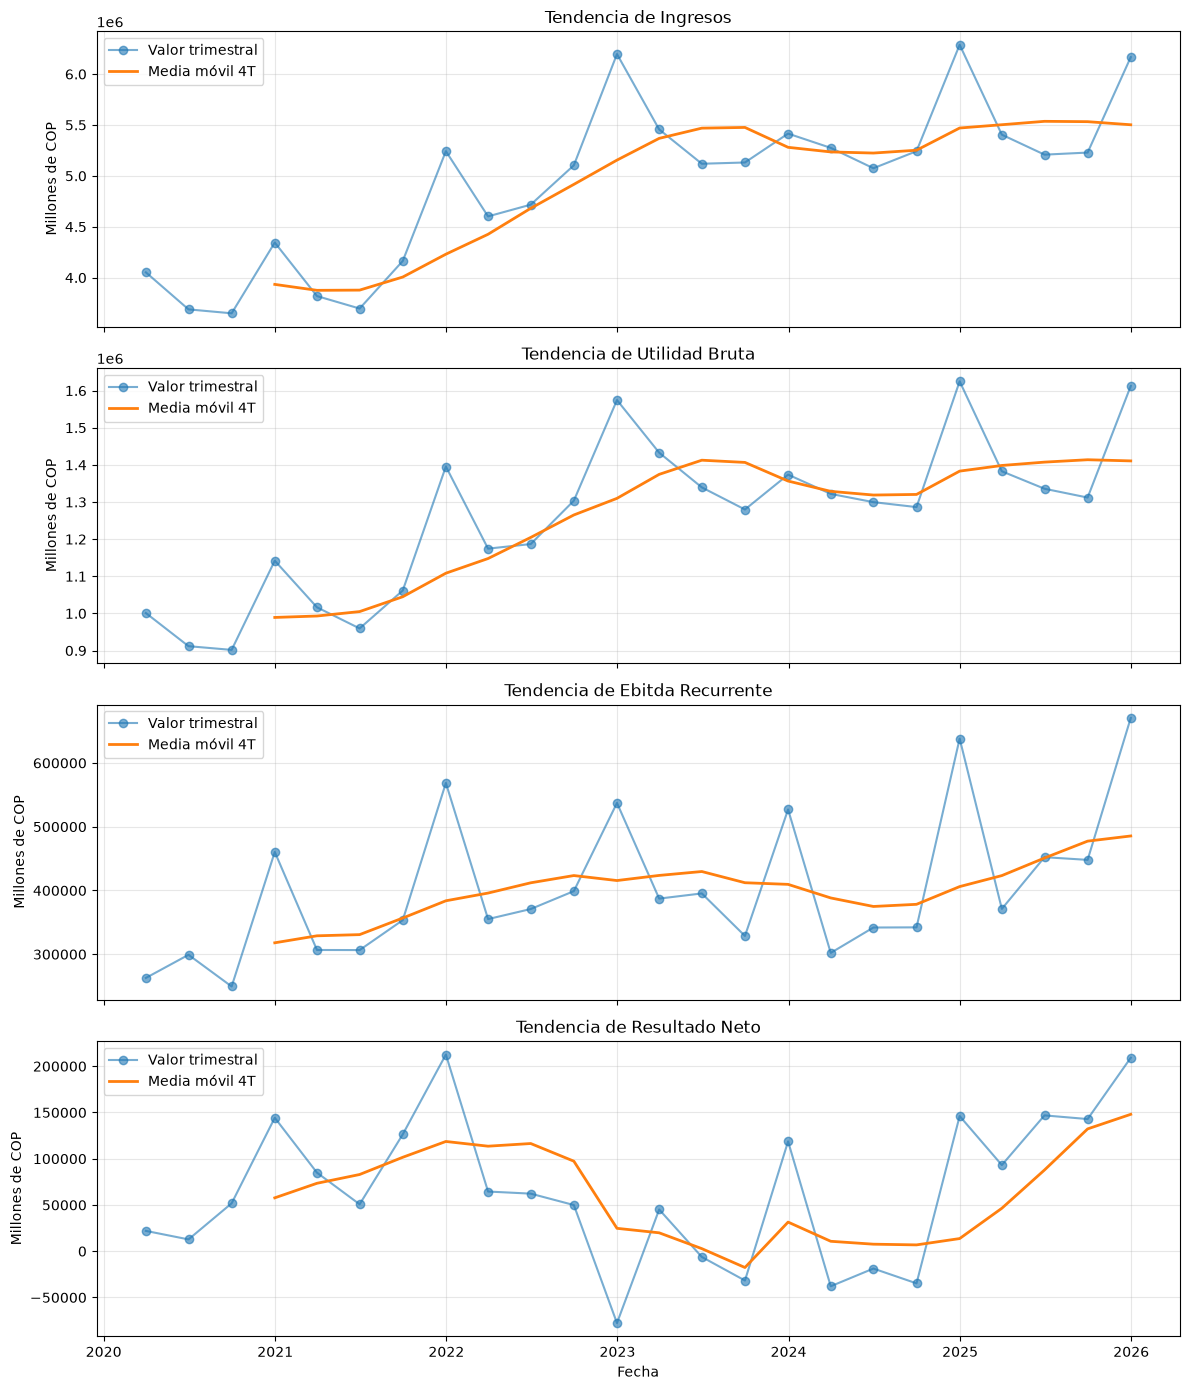

In [67]:
# Gráfico de variación 

fig, ax_list = plt.subplots(
    4, 1,
    figsize=(12, 14),
    sharex=True
)

for ax, variable in zip(ax_list, variables_financieras):

    ax.plot(
        df_tendencia.index,
        df_tendencia[variable],
        marker="o",
        alpha=0.6,
        label="Valor trimestral"
    )

    ax.plot(
        df_tendencia.index,
        df_tendencia[f"{variable}_media_movil_4t"],
        linewidth=2,
        label="Media móvil 4T"
    )

    ax.set_title(
        f"Tendencia de {variable.replace('_', ' ').title()}"
    )

    ax.set_ylabel("Millones de COP")
    ax.grid(True, alpha=0.3)
    ax.legend()

ax_list[-1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

### Análisis de tendencia mediante media móvil

El análisis de las medias móviles de cuatro trimestres permite identificar la tendencia subyacente de las variables financieras, reduciendo parcialmente el efecto de las fluctuaciones trimestrales y de la estacionalidad.

Los ingresos presentan una tendencia general creciente durante el período 2020–2025, aunque con una desaceleración hacia los últimos años. La utilidad bruta presenta un comportamiento similar, consistente con la elevada correlación observada entre ambas variables.

El EBITDA recurrente muestra una mayor variabilidad respecto a los ingresos y la utilidad bruta. La media móvil evidencia una disminución durante parte de 2024, seguida de una recuperación durante 2025.

El resultado neto presenta el comportamiento más volátil de las cuatro variables. La media móvil muestra un deterioro significativo entre 2022 y 2024, seguido de una recuperación durante 2025. Este comportamiento es consistente con los períodos de margen neto negativo identificados previamente.

En conjunto, el análisis confirma que los ingresos y la utilidad bruta presentan tendencias relativamente estables, mientras que el EBITDA recurrente y especialmente el resultado neto presentan una mayor variabilidad. Esta característica deberá considerarse posteriormente en la selección de variables y modelos de pronóstico.

In [68]:
# Volatilidad movil 
# Desviación estandar movil de 4 trimestres

for variable in variables_financieras:
    df_tendencia[f"{variable}_volatilidad_4t"] = (
        df_tendencia[variable]
        .rolling(window=4)
        .std()
    )

df_tendencia[
    [
        f"{variable}_volatilidad_4t"
        for variable in variables_financieras
    ]
].round(2)

,ingresos_volatilidad_4t,utilidad_bruta_volatilidad_4t,ebitda_recurrente_volatilidad_4t,resultado_neto_volatilidad_4t
fecha,,,,
2020-03-31,NaN,NaN,NaN,NaN
2020-06-30,NaN,NaN,NaN,NaN
2020-09-30,NaN,NaN,NaN,NaN
2020-12-31,328603.15,111226.68,97268.10,60066.71
2021-03-31,321184.49,112039.89,91268.19,55671.60
2021-06-30,319607.96,102652.37,90533.94,43865.57
2021-09-30,300237.54,77021.15,72536.74,42016.17
2021-12-31,703106.06,196031.69,125158.74,69866.57
2022-03-31,657907.97,187067.33,117298.26,73786.63


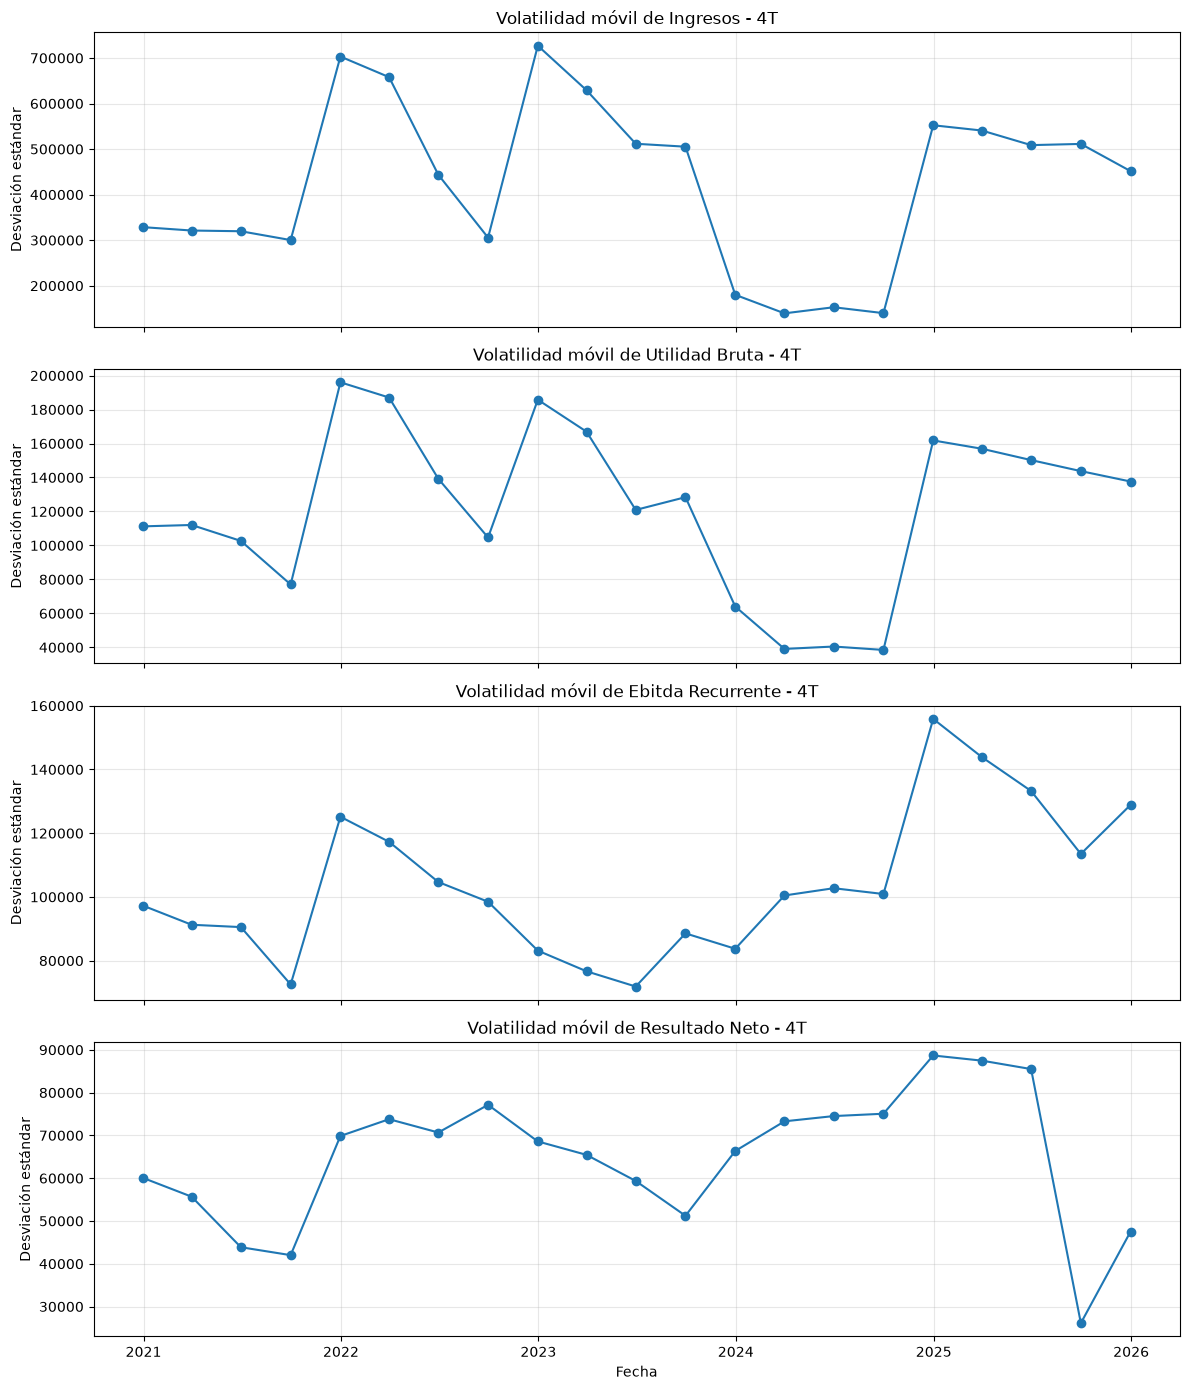

In [69]:
# Gráfico de volatilidad

fig, ax_list = plt.subplots(
    4, 1,
    figsize=(12, 14),
    sharex=True
)

for ax, variable in zip(ax_list, variables_financieras):

    ax.plot(
        df_tendencia.index,
        df_tendencia[f"{variable}_volatilidad_4t"],
        marker="o"
    )

    ax.set_title(
        f"Volatilidad móvil de {variable.replace('_', ' ').title()} - 4T"
    )

    ax.set_ylabel("Desviación estándar")
    ax.grid(True, alpha=0.3)

ax_list[-1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

### Análisis de volatilidad móvil

El análisis de la desviación estándar móvil de cuatro trimestres permite identificar cambios en la variabilidad reciente de las variables financieras.

Los ingresos y la utilidad bruta presentan patrones de volatilidad similares, con incrementos importantes durante 2022–2023, una reducción durante 2024 y un nuevo aumento durante 2025. Este comportamiento es consistente con la elevada correlación observada entre ambas variables.

El EBITDA recurrente presenta una dinámica diferente. Después de una reducción de su volatilidad durante 2023, se observa un incremento durante 2024 y un máximo alrededor de 2025-T1, seguido de una disminución hacia los últimos períodos analizados.

El resultado neto presenta una volatilidad elevada y un comportamiento más irregular. Su variabilidad aumenta durante 2022 y permanece elevada durante 2023–2024, alcanzando uno de sus mayores niveles alrededor de 2025-T1. Posteriormente se observa una reducción considerable.

Debe considerarse que la volatilidad móvil fue calculada utilizando una ventana de cuatro trimestres. Por lo tanto, sus resultados deben interpretarse como una medida de variabilidad reciente y no como una medida definitiva de la volatilidad estructural de cada variable.